# ECSE415 - Introduction to Computer Vision
## Tutorial 9 - Face detectors

In [1]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/ECSE 415 Tutorials/Tutorial 7/'
print(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ECSE 415 Tutorials/Tutorial 7/


## PCA Example

In [2]:
import sklearn
from sklearn import datasets
from matplotlib import pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import os
import cv2

import sys
sys.path.append(path)
import tutorial7_utils

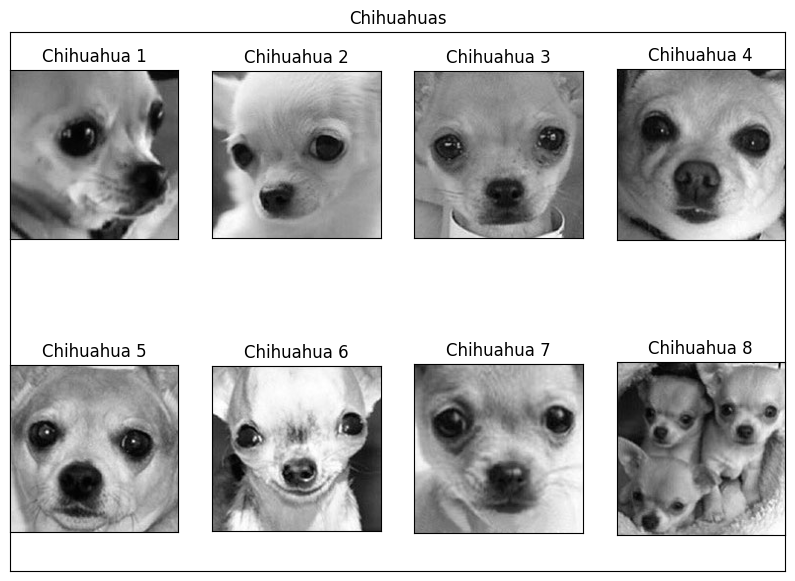

In [3]:
# Read the images and convert to grayscale
chihuahuas = [cv2.imread(path+f'images/chihuahua-{i}.jpg', cv2.IMREAD_GRAYSCALE) for i in range(1,9)]
muffins = [cv2.imread(path+f'images/muffin-{i}.jpeg', cv2.IMREAD_GRAYSCALE) for i in range(1,9)]

# Display the chihuahuas
plt.figure(figsize=(10,7))
plt.title('Chihuahuas'), plt.xticks([]), plt.yticks([])
for i in range(8):
  plt.subplot(2,4,i+1)
  plt.title(f"Chihuahua {i+1}"), plt.xticks([]), plt.yticks([])
  plt.imshow(chihuahuas[i], cmap='grey')
plt.show()

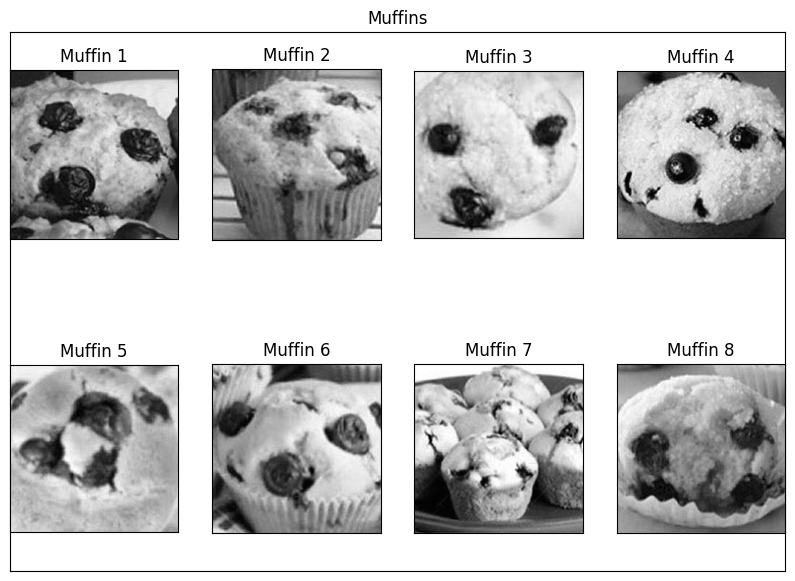

In [4]:
# Display the muffins
plt.figure(figsize=(10,7))
plt.title('Muffins'), plt.xticks([]), plt.yticks([])
for i in range(8):
  plt.subplot(2,4,i+1)
  plt.title(f"Muffin {i+1}"), plt.xticks([]), plt.yticks([])
  plt.imshow(muffins[i], cmap='grey')
plt.show()

In [5]:
# Resizing all images to have the same dimensions before applying PCA
# 1. Decide on the dimensions (w, h) for the images
# 2. cv2.resize() for all images in the dataset
chihuahuas_resized, muffins_resized, height, width = tutorial7_utils.resize_images(chihuahuas, muffins)

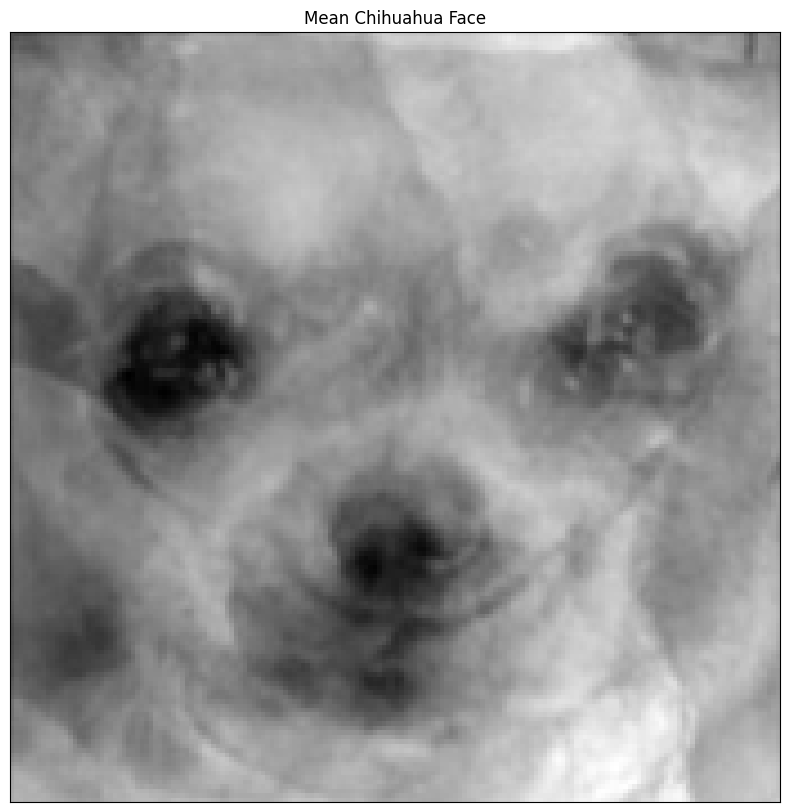

In [6]:
# Compute the mean chihuahua face and display

chihuahua_mean = np.mean(chihuahuas_resized, axis=0)
chihuahua_mean_vector = np.array([chihuahua_mean.flatten()]).transpose()

plt.figure(figsize=(10,10))
plt.title("Mean Chihuahua Face"), plt.xticks([]), plt.yticks([])
plt.imshow(chihuahua_mean, cmap='grey')
plt.show()

In [7]:
# Finding the eigenvectors and eigenvalues of the covariance matrix using snapshot method

# Very important to FLATTEN and CENTER the data
chihuahua_dataset = np.array([chihuahuas_resized[i].flatten() for i in range(chihuahuas_resized.shape[0])]).transpose()
chihuahua_dataset_centered = chihuahua_dataset - chihuahua_mean_vector
muffin_dataset = np.array([muffins_resized[i].flatten() for i in range(muffins_resized.shape[0])]).transpose()
muffin_dataset_centered = muffin_dataset - chihuahua_mean_vector

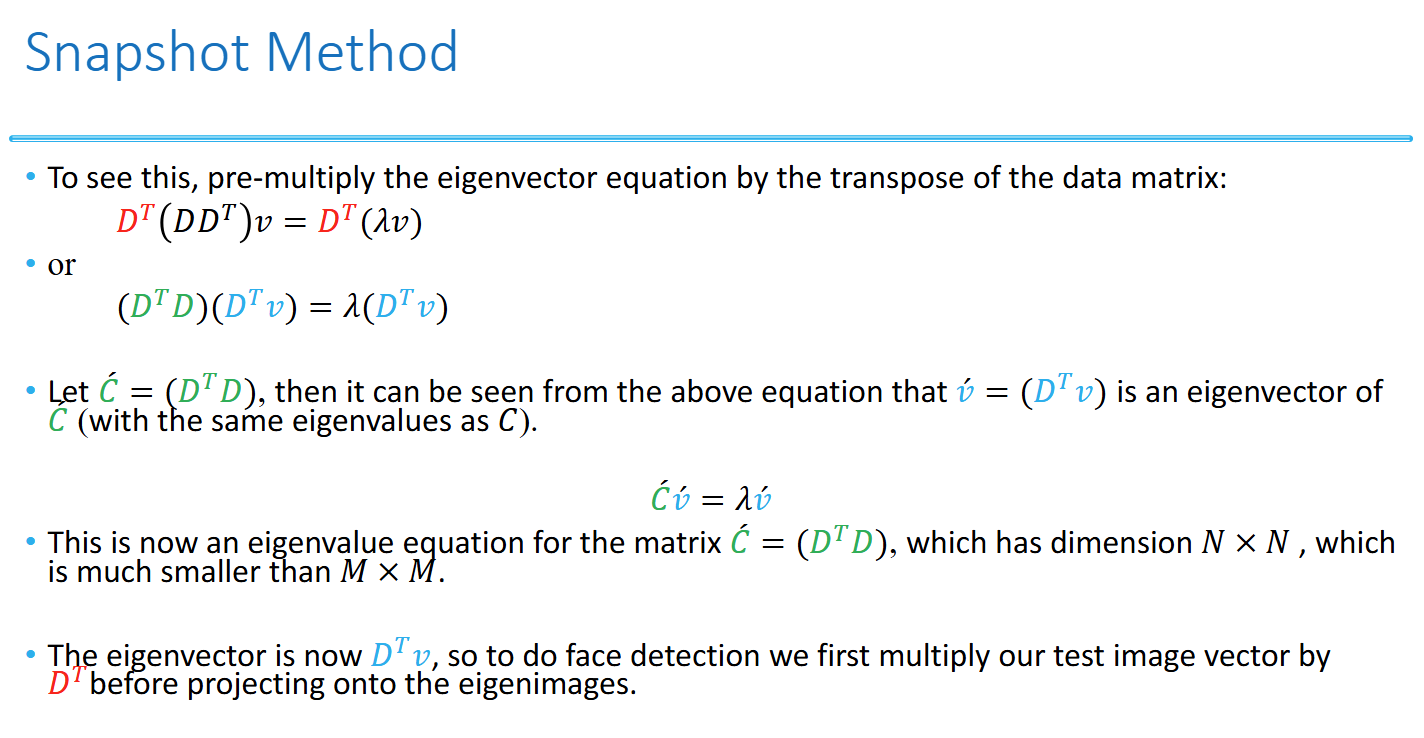

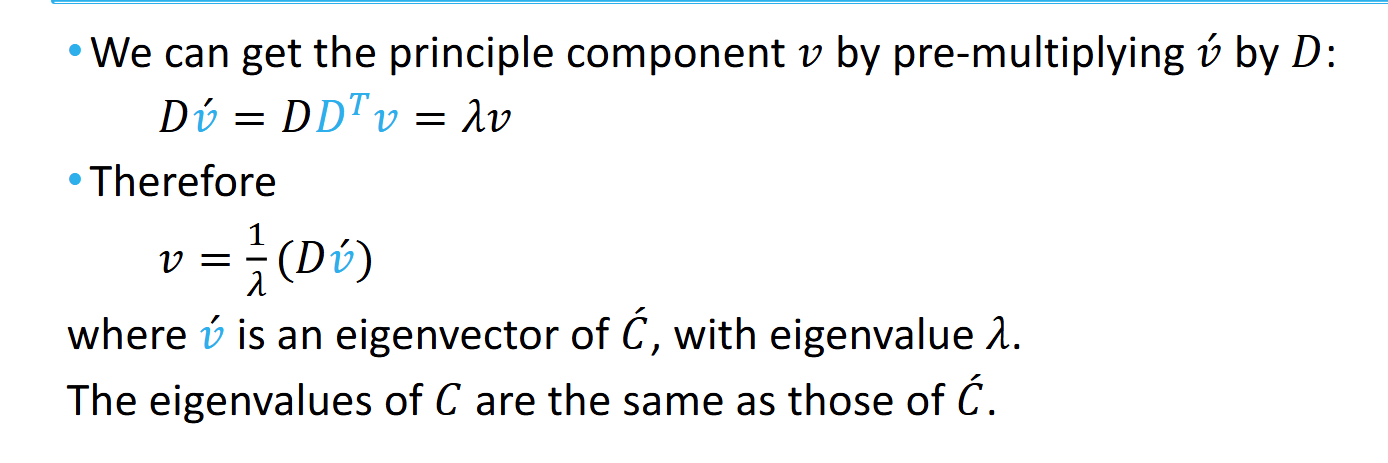

In [8]:
# Computing eigenfaces and eigenvalues using snapshot:
# - Method 1: 1. Use np.linalg.eigh(D.T @ D)
#             2. eigenvectors = D @ eigenvectors_found_with_np_linalg_eigh
#             3. Normalized eigenvectors
#             4. Eigenvalues obtained from np.linalg.eigh() can be kept as is
# - Method 2: 1. Use np.linalg.svd(D)
#             2. eigenvalues = eigenvalues_found_with_np_linalg_eigh ** 2
#             3. Eigenvectors obtained from np.linalg.svd() can be kept as is

# We show below that both methods give the same results
# Note that the eigenvectors can be flipped in sign and it is fine since the eigenvectors -v and v have the same eigenvalue lambda
sorted_eigenchihuahuas_svd, sorted_eigenchihuahua_values_svd, sorted_eigenchihuahua_vectors_cov, sorted_eigenchihuahua_values_cov = tutorial7_utils.finding_eigenfaces(chihuahua_dataset_centered)

print('Top eigenvectors with associated eigenvalues in descending order using np.linalg.svd():')
for eigenchihuahua in sorted_eigenchihuahuas_svd:
  print(f'Eigenvalue: {eigenchihuahua[0]}, Eigenvector: {eigenchihuahua[1]}')
print("*********************************************************************************")

print('Top eigenvectors with associated eigenvalues in descending order using np.linalg.eigh():')
for eigenface, eigenval in zip(sorted_eigenchihuahua_vectors_cov, sorted_eigenchihuahua_values_cov):
  print(f'Eigenvalue: {eigenval}, Eigenvector: {eigenface}')

Top eigenvectors with associated eigenvalues in descending order using np.linalg.svd():
Eigenvalue: 202462144.29822993, Eigenvector: [ 0.00557516  0.00616521  0.00663762 ... -0.00803065 -0.00759075
 -0.00740953]
Eigenvalue: 140016863.8376734, Eigenvector: [-0.00336975 -0.00608878 -0.00565434 ...  0.00856024  0.00900395
  0.00919302]
Eigenvalue: 90926611.16696207, Eigenvector: [-0.00465572 -0.00203663 -0.00173191 ...  0.00171987  0.00235059
  0.00308672]
Eigenvalue: 74430557.83969592, Eigenvector: [0.00176375 0.00363496 0.00190436 ... 0.01273116 0.01274859 0.0121635 ]
Eigenvalue: 67199271.66974027, Eigenvector: [0.01263189 0.01019503 0.00870629 ... 0.00190979 0.00223359 0.00227928]
Eigenvalue: 41149597.598426156, Eigenvector: [ 0.01129256  0.01096073  0.00854659 ... -0.00319573 -0.00262677
 -0.00214924]
Eigenvalue: 33767991.46427202, Eigenvector: [ 0.00274288  0.00264731  0.00298147 ... -0.00897519 -0.00883172
 -0.00666814]
Eigenvalue: 1.0743365961438957e-21, Eigenvector: [ 5.42009142e-

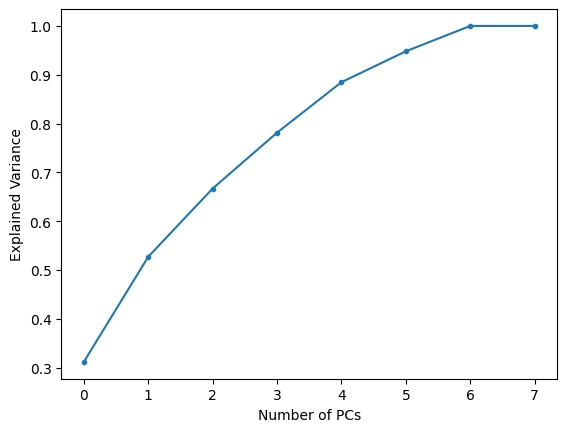

In [9]:
# Explained Variance Ratio -> Cumulative Variance Plot
# eig_1, eig_2, eig_3, eig_4, ...
# Explained_Variance_1 =  (eig_1) / (eig_1 + eig_2 + eig_3 + ... + eig_20)
# Explained_Variance_2 =  (eig_1 + eig_2) / (eig_1 + eig_2 + eig_3 + ... + eig_20)
# Explained_Variance_3 =  (eig_1 + eig_2 + eig_3) / (eig_1 + eig_2 + eig_3 + ... + eig_20)

plt.figure()
plt.plot(np.cumsum(sorted_eigenchihuahua_values_svd) / np.sum(sorted_eigenchihuahua_values_svd),'.-')
plt.xlabel('Number of PCs')
plt.ylabel('Explained Variance')
plt.show()

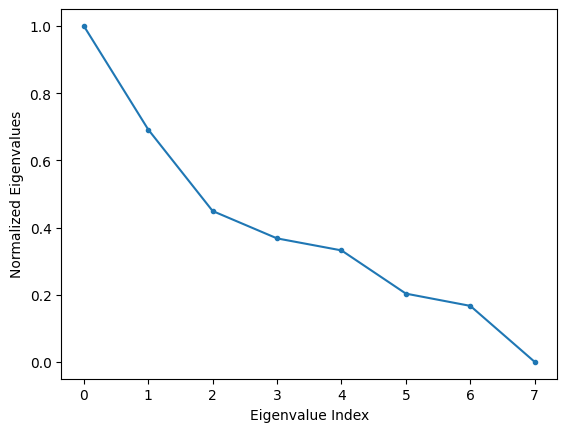

In [10]:
# Normalized Eigenvalues
normalized_eigenvalues = sorted_eigenchihuahua_values_svd / np.array(sorted_eigenchihuahua_values_svd).max()

plt.figure()
plt.plot(normalized_eigenvalues,'.-')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Normalized Eigenvalues')
plt.show()

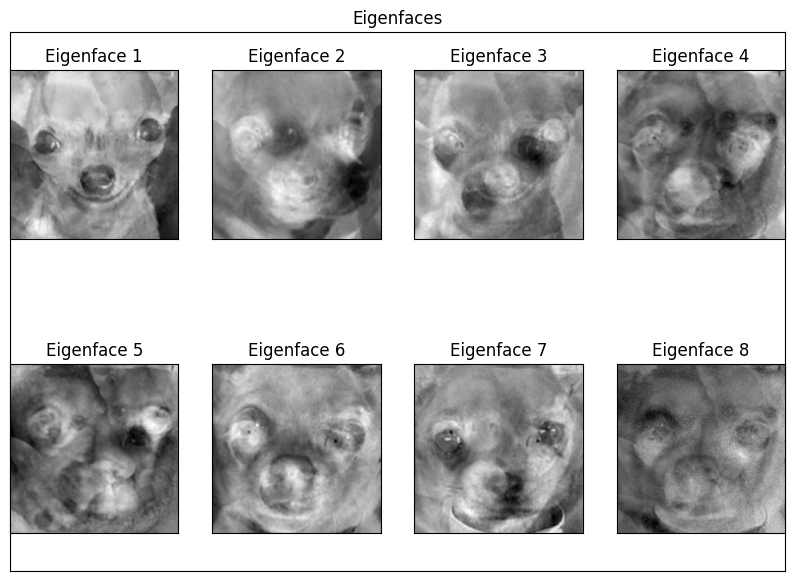

In [17]:
# Showcasing the EigenFaces
plt.figure(figsize=(10,7))
plt.title('Eigenfaces'), plt.xticks([]), plt.yticks([])
for i in range(8):
  plt.subplot(2,4,i+1)
  plt.title(f"Eigenface {i+1}"), plt.xticks([]), plt.yticks([])
  plt.imshow(sorted_eigenchihuahua_vectors_cov[i].reshape(height,width), cmap='grey')
plt.show()

### How many PCs are sufficient?

**For Data Reconstruction (Explained Variance Approach)**:

If your objective is to retain as much information as possible while reducing dimensionality, you can select the number of PCs based on the explained variance.

- Explained Variance Ratio: Each PC explains a portion of the variance in the data. You can sum up the variance explained by each PC and select enough PCs to reach a desired threshold, such as 90% or 95% of the total variance.

Steps:
- Apply PCA and get the explained variance ratio of each PC.
- Create a cumulative variance plot (scree plot).
- Select the number of PCs that explain the target percentage of variance (e.g., 95%).

**For Downstream Tasks (Task-Specific Performance)**:

If the PCA is used as a preprocessing step for tasks like classification, detection, or identification, the optimal number of PCs should be determined by evaluating the performance of your model on the downstream task.

In [18]:
# Choose number of PCs where explained variance reaches 90%
# np.argmax() returns the index of the first occurrence of the maximum value in the input array
n_components = np.argmax(np.cumsum(sorted_eigenchihuahua_values_cov) / np.sum(sorted_eigenchihuahua_values_cov) >= 0.90) + 1
print(f"Number of PCs needed to explain 90% of variance: {n_components}")

Number of PCs needed to explain 90% of variance: 6


## Face Reconstruction
$$X_{reconstructed} = X_{mean} + X_{pca} \cdot E_n ^ T$$

$X_{mean}$ is the average face.

$E_n$ is the matrix containing the first
n rows of the eigenfaces matrix
$E$.

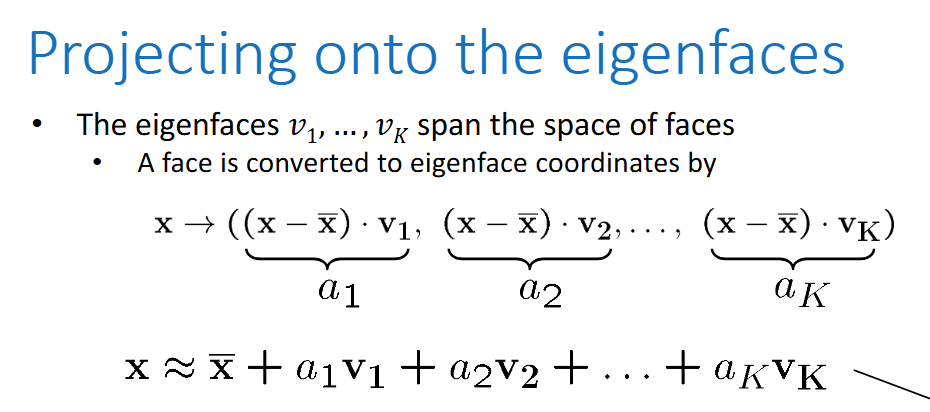

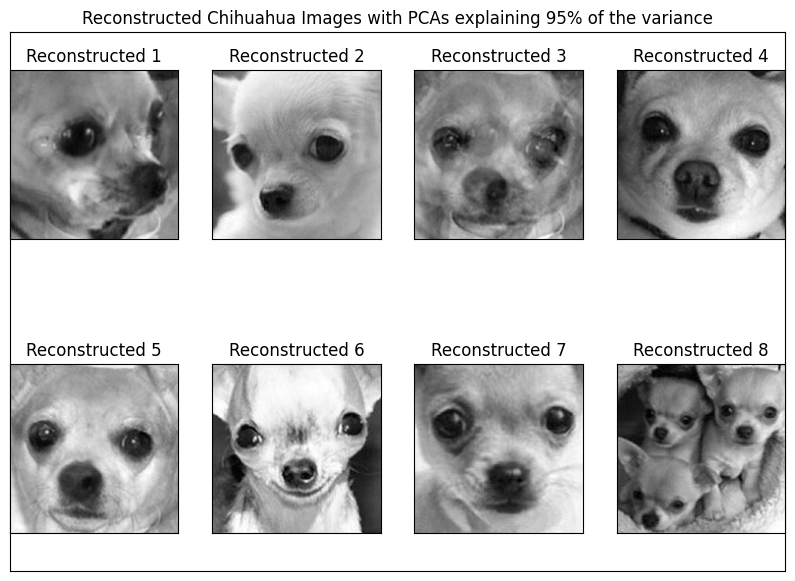

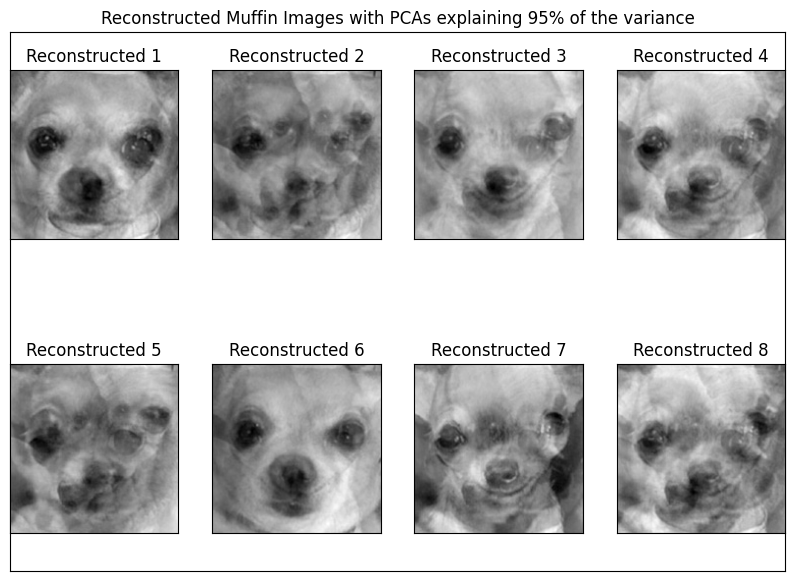

In [19]:
# Reconstruct the faces
PCAs_90 = sorted_eigenchihuahua_vectors_cov[:n_components].T

# Projecting the images
projected_chihuahuas_90 = np.matmul(PCAs_90.T, chihuahua_dataset_centered)
projected_muffins_90 = np.matmul(PCAs_90.T, muffin_dataset_centered)
# Reconstructing the images
reconstructed_chihuahuas_90 = chihuahua_mean_vector + np.matmul(PCAs_90, projected_chihuahuas_90)
reconstructed_muffins_90 = chihuahua_mean_vector + np.matmul(PCAs_90, projected_muffins_90)

# Visualizing the reconstructions
plt.figure(figsize=(10,7))
plt.title('Reconstructed Chihuahua Images with PCAs explaining 90% of the variance'), plt.xticks([]), plt.yticks([])
for i in range(8):
  plt.subplot(2,4,i+1)
  plt.title(f"Reconstructed {i+1}"), plt.xticks([]), plt.yticks([])
  plt.imshow(reconstructed_chihuahuas_90.transpose()[i].reshape(height, width), cmap='grey')
plt.show()

plt.figure(figsize=(10,7))
plt.title('Reconstructed Muffin Images with PCAs explaining 90% of the variance'), plt.xticks([]), plt.yticks([])
for i in range(8):
  plt.subplot(2,4,i+1)
  plt.title(f"Reconstructed {i+1}"), plt.xticks([]), plt.yticks([])
  plt.imshow(reconstructed_muffins_90.transpose()[i].reshape(height, width), cmap='grey')
plt.show()


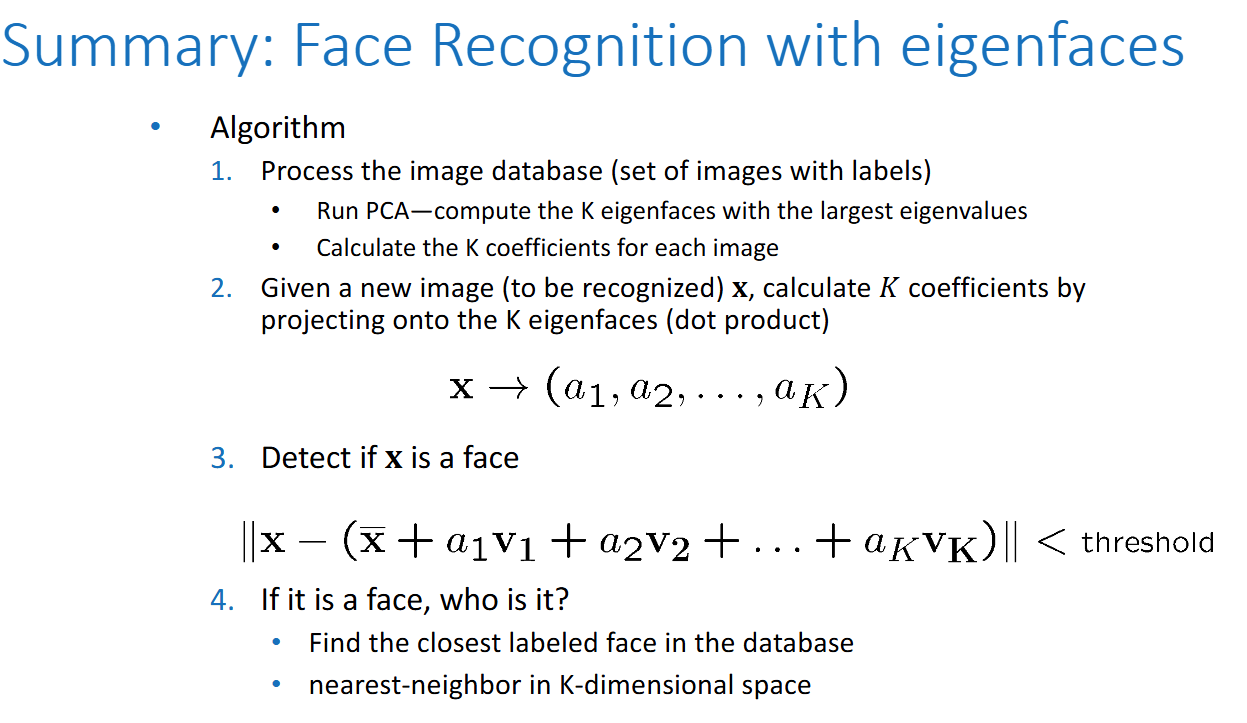

In [21]:
# Reconstruction errors
# Computing reconstruction errors
chihuahua_reconstruction_errors_90 = [np.linalg.norm(v[0]-v[1]) for v in zip(chihuahua_dataset.T, reconstructed_chihuahuas_90.T)]
muffin_reconstruction_errors_90 = [np.linalg.norm(v[0]-v[1]) for v in zip(muffin_dataset.T, reconstructed_muffins_90.T)]

print(f"chihuahua_reconstruction_errors_90: {chihuahua_reconstruction_errors_90}")
print(f"muffin_reconstruction_errors_90: {muffin_reconstruction_errors_90}")

chihuahua_reconstruction_errors_90: [np.float64(2347.8539116420516), np.float64(707.4361489010595), np.float64(4518.254398589609), np.float64(421.4160513143719), np.float64(2513.2895249465023), np.float64(22.52258805381317), np.float64(632.8929478684609), np.float64(667.2393002269048)]
muffin_reconstruction_errors_90: [np.float64(10885.570737747352), np.float64(9510.239755575802), np.float64(8823.506515654202), np.float64(13330.73516011518), np.float64(8505.033199577829), np.float64(9753.660011158241), np.float64(13254.939844998573), np.float64(8726.573623188824)]


### Chihuahua Detector
- Use the reconstruction error as a metric to know if an image is a chihuahua or not
- The lower the reconstruction error the more certain we are that the image is a chihuahua
- So to classify images we need a threshold
- During training make sure that the threshold classifies most chihuahua images as chihuahuas and most non-chihuahua images as not chihuahuas.
- You also want to make sure that the margin between the outliers of the validation set and the boundary (threshold) is largest.

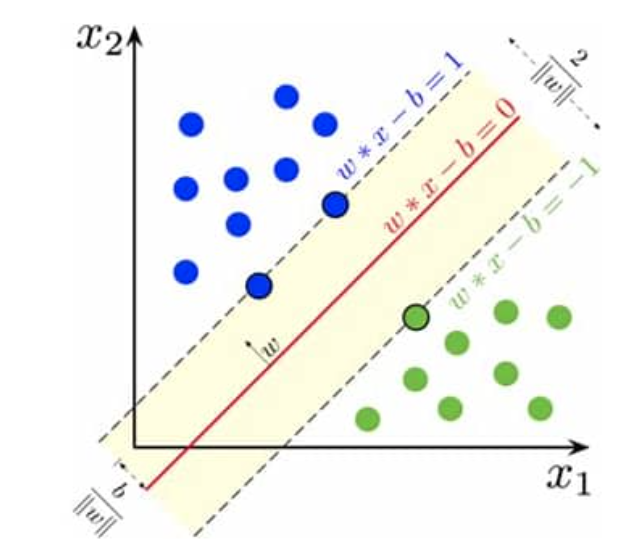